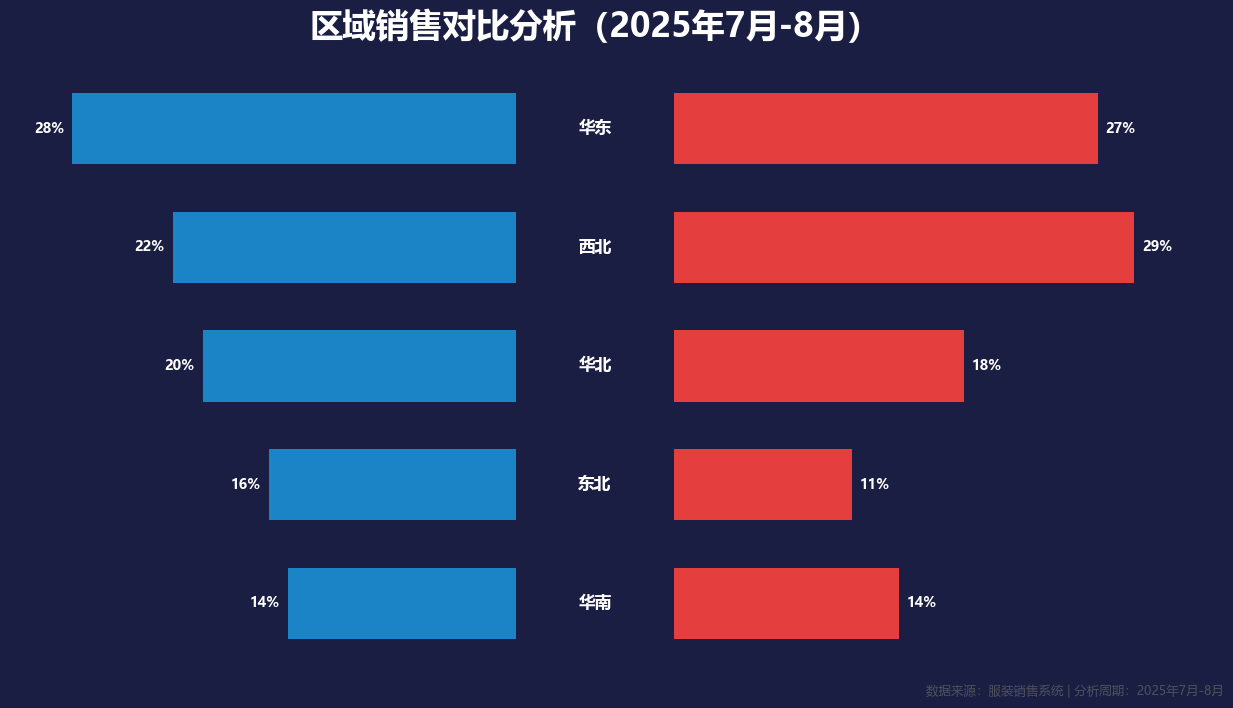

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# 区域划分映射
REGION_MAP = {
    "华南": ["广东省", "广西壮族自治区", "海南省", "福建省"],
    "华北": ["北京市", "天津市", "河北省", "山西省", "内蒙古自治区"],
    "东北": ["辽宁省", "吉林省", "黑龙江省"],
    "西北": ["陕西省", "甘肃省", "青海省", "宁夏回族自治区", "新疆维吾尔自治区"],
    "华东": ["上海市", "江苏省", "浙江省", "安徽省", "山东省", "江西省"]
}

def get_region(province: str) -> str:
    """根据省份确定所属区域"""
    for region, provinces in REGION_MAP.items():
        if province in provinces:
            return region
    return "其他"

# 读取生成的数据集
try:
    # 严格读取CSV文件
    orders = pd.read_csv('../../数据生成/erp_order.csv', encoding='utf-8-sig')
    
    # 检查必要的列是否存在
    required_columns = ['下单时间', '省份', '商品金额']
    for col in required_columns:
        if col not in orders.columns:
            raise ValueError(f"订单数据中缺少必要列: {col}")
    
    # 转换日期列
    orders['下单时间'] = pd.to_datetime(orders['下单时间'], errors='coerce')
    
    # 过滤无效日期
    orders = orders[orders['下单时间'].notnull()]
    
    # 添加区域列
    orders['区域'] = orders['省份'].apply(get_region)
    
    # 过滤掉"其他"区域
    orders = orders[orders['区域'] != "其他"]
    
    # 提取年份和月份
    orders['年份'] = orders['下单时间'].dt.year
    orders['月份'] = orders['下单时间'].dt.month
    
    # 确保只有2025年7月和8月的数据
    orders = orders[(orders['年份'] == 2025) & (orders['月份'].isin([7, 8]))]
    
    if orders.empty:
        raise ValueError("没有2025年7月或8月的订单数据")
    
    # 创建月份标识列（2025年7月/2025年8月）
    orders['月份标识'] = orders.apply(
        lambda x: f"2025年{x['月份']}月", 
        axis=1
    )
    
    # 按区域和月份标识汇总销售数据
    region_sales = orders.groupby(['区域', '月份标识'])['商品金额'].sum().reset_index()
    
    # 转换为宽格式
    pivot_data = region_sales.pivot(index='区域', columns='月份标识', values='商品金额').reset_index()
    
    # 确保两个月份都有数据
    required_months = ['2025年7月', '2025年8月']
    for month in required_months:
        if month not in pivot_data.columns:
            pivot_data[month] = 0
    
    # 填充缺失值为0
    pivot_data = pivot_data.fillna(0)
    
    # 转换为数值类型
    pivot_data['2025年7月'] = pd.to_numeric(pivot_data['2025年7月'], errors='coerce').fillna(0)
    pivot_data['2025年8月'] = pd.to_numeric(pivot_data['2025年8月'], errors='coerce').fillna(0)
    
    # 计算总销售额
    total_sales_may = pivot_data['2025年7月'].sum()
    total_sales_jun = pivot_data['2025年8月'].sum()
    
    # 计算百分比
    pivot_data['2025年7月占比'] = (pivot_data['2025年7月'] / total_sales_may * 100).round(1)
    pivot_data['2025年8月占比'] = (pivot_data['2025年8月'] / total_sales_jun * 100).round(1)
    
    # 按2025年6月占比排序
    pivot_data = pivot_data.sort_values(by='2025年8月占比', ascending=True)
    
    # 创建深色背景的图表
    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    fig.patch.set_facecolor('#1A1E43')  # 深蓝色背景
    ax.set_facecolor('#1A1E43')
    
    # 设置坐标
    y = np.arange(len(pivot_data))
    
    # 获取占比数据并转换为纯Python列表
    sales_jun_percent = pivot_data['2025年8月占比'].tolist()
    sales_may_percent = pivot_data['2025年7月占比'].tolist()
    regions = pivot_data['区域'].tolist()
    
    # 定义中心空白区域大小 (固定值，确保区域文字有足够空间)
    gap_size = 5  # 固定空白区域大小为5%
    
    # 创建8月数据（左侧，蓝色）- 不延伸到0，留出空白
    bars_jun = ax.barh(
        y, 
        [-x for x in sales_jun_percent],  # 蓝色柱体的长度
        left=-gap_size,  # 从-gap_size开始（不延伸到0）
        color='#1a84c7',  # 蓝色
        edgecolor='none',
        height=0.6
    )
    
    # 创建7月数据（右侧，红色）- 从gap_size开始
    bars_may = ax.barh(
        y, 
        sales_may_percent,  # 红色柱体的长度
        left=gap_size,  # 从gap_size开始（不从0开始）
        color='#e53e3e',  # 红色
        edgecolor='none',
        height=0.6
    )
    
    # 移除边框
    for spine in ax.spines.values():
        spine.set_visible(False)
    
        # 添加顶部标题
    plt.figtext(0.5, 0.97, '区域销售对比分析（2025年7月-8月）', 
                ha='center', fontsize=24, color="#ffffff", fontweight='bold')
    
    # 设置X轴 - 确保有足够的空间
    max_val = max(max(sales_jun_percent), max(sales_may_percent)) * 1.1
    ax.set_xlim(-max_val - gap_size, max_val + gap_size)
    ax.set_xticks([])
    
    # 设置Y轴
    ax.set_yticks(y)
    # 不显示默认y标签
    ax.set_yticklabels([''] * len(regions))

    # 隐藏X轴和Y轴的标签刻度
    ax.tick_params(axis='x', which='both', length=0)  # 隐藏X轴的刻度
    ax.tick_params(axis='y', which='both', length=0)  # 隐藏Y轴的刻度
    
    # 添加区域名称标签（放在中心空白处）
    for i, region in enumerate(regions):
        # 文字放在x=0位置，即蓝色和红色柱体的交界处
        ax.text(0, i, region, 
                ha='center', 
                va='center', 
                color='white',
                fontsize=12,
                fontweight='bold',
                zorder=10)  # 确保文字在柱体之上
    
    # 添加数据标签 - 百分比数值
    for i, (bar_jun, bar_may) in enumerate(zip(bars_jun, bars_may)):
        # 6月标签（左侧）- 百分比
        # 获取柱体长度
        width_jun = bar_jun.get_width()
        # 柱体实际开始位置
        left_jun = bar_jun.get_x()
        # 计算柱体末端位置
        end_jun = left_jun + width_jun
        
        ax.annotate(
            f"{sales_jun_percent[i]:.0f}%",
            xy=(end_jun - 0.5, i),
            ha='right',
            va='center',
            fontsize=10,
            color='white',
            fontweight='bold',
            zorder=5
        )
        
        # 5月标签（右侧）- 百分比
        # 获取柱体长度
        width_may = bar_may.get_width()
        # 柱体实际开始位置
        left_may = bar_may.get_x()
        # 计算柱体末端位置
        end_may = left_may + width_may
        
        ax.annotate(
            f"{sales_may_percent[i]:.0f}%",
            xy=(end_may + 0.5, i),
            ha='left',
            va='center',
            fontsize=10,
            color='white',
            fontweight='bold',
            zorder=5
        )
    
    # 添加底部装饰
    plt.figtext(0.9, 0.03, 
                '数据来源：服装销售系统 | 分析周期：2025年7月-8月', 
                ha='center', 
                fontsize=9, 
                color='#666666',
                alpha=0.7)
    
    plt.tight_layout(rect=(0.0, 0.05, 1.0, 0.95))
    
    # 保存高清图片
    plt.savefig('区域销售占比分析（2025年7月-8月）.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    
    plt.show()
    
except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 分析：

- **华东区域**：
  在2025年7月至8月期间，华东区域的销售占比最高，达到28%，显示出该区域在整体市场中占据显著的份额，可能与该地区的经济发展水平和消费者购买力有关。

- **西北区域**：
  西北区域的销售占比为22%，位居第二，表明该区域同样具有较高的市场活跃度和需求潜力。

- **华北区域**：
  华北区域的销售占比为20%，略低于西北区域，显示出该区域的市场表现稳定，可能与该地区的人口密度和消费习惯有关。

- **东北区域**：
  东北区域的销售占比为16%，显示出该区域的市场活跃度相对较低，可能需要进一步分析其市场策略和消费者行为。

- **华南区域**：
  华南区域的销售占比为14%，与东北区域相同，显示出该区域的市场活跃度相对较低，可能需要进一步分析其市场策略和消费者行为。

- **西南区域**：
  西南区域的销售占比最高，为29%，显示出该区域在整体市场中占据显著的份额，可能与该地区的经济发展水平和消费者购买力有关。


# 结论：

从区域销售占比的分布来看，华东和西南区域在市场中表现最为突出，显示出其强大的市场吸引力和用户基础。西北和华北区域也显示出较强的市场潜力，而东北和华南区域的销售占比相对较低，可能需要进一步分析其市场策略和用户定位。这些数据为进一步的市场分析和策略制定提供了基础，有助于理解不同区域的市场动态和消费者需求。